In [ ]:
%run bootstrap.ipynb

# Expectation-Maximization (Section 20.3)

The three instances of EM from the book, implemented in [`learning.py`](learning.py) and [`probability.py`](probability.py).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aima.learning import gaussian_mixture_em, naive_bayes_em
from aima.probability import baum_welch, HiddenMarkovModel, T, F

## 20.3.1 Unsupervised clustering: mixture of Gaussians
EM recovers two Gaussian blobs without any labels.

recovered means:
 [[-0.03  0.02]
 [ 8.01  7.94]]


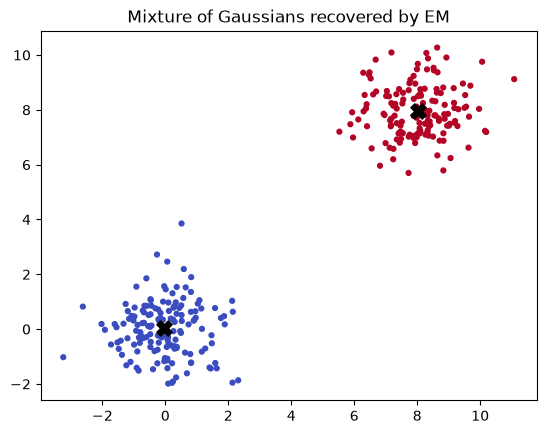

In [2]:
np.random.seed(42)
data = np.vstack([np.random.randn(150, 2) + [0, 0], np.random.randn(150, 2) + [8, 8]])
model = gaussian_mixture_em(data, k=2)
print('recovered means:\n', np.round(model['means'], 2))
labels = model['responsibilities'].argmax(axis=1)
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='coolwarm', s=12)
plt.scatter(model['means'][:, 0], model['means'][:, 1], c='black', marker='X', s=120)
plt.title('Mixture of Gaussians recovered by EM'); plt.show()

## 20.3.2 Bayes net with a hidden variable: the candy bags
Two bags of candy are mixed; the bag is hidden. EM recovers each bag's feature probabilities (bag 1 ~ 0.8, bag 2 ~ 0.3).

In [3]:
np.random.seed(0)
bag1 = (np.random.rand(1000, 3) < 0.8).astype(int)
bag2 = (np.random.rand(1000, 3) < 0.3).astype(int)
candy = naive_bayes_em(np.vstack([bag1, bag2]), k=2)
print('class weights      :', np.round(candy['weights'], 3))
print('P(feature=1 | bag) :\n', np.round(candy['probabilities'], 3))

class weights      : [0.528 0.472]
P(feature=1 | bag) :
 [[0.767 0.769 0.792]
 [0.287 0.308 0.308]]


## 20.3.3 Learning an HMM: Baum-Welch
Starting from a guess, Baum-Welch increases the likelihood of the umbrella observation sequence at every iteration.

In [4]:
hmm = HiddenMarkovModel([[0.7, 0.3], [0.3, 0.7]], [[0.9, 0.2], [0.1, 0.8]])
obs = [T, T, F, T, T, F, F, F, T, F, T, T]

def loglik(h, obs):
    A, sensor = np.array(h.transition_model), np.array(h.sensor_model)
    B = np.array([sensor[0] if e else sensor[1] for e in obs])
    a = np.array(h.prior) * B[0]; ll = np.log(a.sum()); a /= a.sum()
    for t in range(1, len(obs)):
        a = B[t] * (a @ A); ll += np.log(a.sum()); a /= a.sum()
    return ll

lls = [loglik(baum_welch(hmm, obs, iterations=k), obs) for k in range(0, 21, 2)]
print('log-likelihood per iteration:', [round(x, 3) for x in lls])
print('monotonically non-decreasing:', all(b >= a - 1e-9 for a, b in zip(lls, lls[1:])))

log-likelihood per iteration: [np.float64(-8.676), np.float64(-7.811), np.float64(-7.712), np.float64(-7.666), np.float64(-7.637), np.float64(-7.617), np.float64(-7.603), np.float64(-7.594), np.float64(-7.587), np.float64(-7.582), np.float64(-7.579)]
monotonically non-decreasing: True
